# Experimentos adicionales de modelado

Este notebook extiende `02_model_training.ipynb` con una exploración más amplia
de modelos, variables y *feature engineering*, priorizando CatBoost y modelos
ensamblados de árboles antes de considerar arquitecturas más complejas
(p. ej. redes neuronales), que quedan fuera del alcance de esta corrida.

Reutiliza el mismo split 60/20/20 y las mismas funciones de evaluación que el
pipeline de producción (`online_shoppers.modeling`) para que los resultados
sean comparables. El test se toca una única vez, al final, sobre el mejor
candidato experimental. Todo se registra en el mismo MLflow local, en un
experimento separado (`online-shoppers-purchase-intention-experiments`) para
no mezclar corridas exploratorias con las que sí participan en la selección
del champion de producción.


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.catboost
import mlflow.sklearn
import numpy as np
import os
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from online_shoppers.data import (
    CATEGORICAL_COLUMNS,
    CONTINUOUS_COLUMNS,
    COUNT_COLUMNS,
    TARGET_COLUMN,
    load_dataset,
)
from online_shoppers.modeling import evaluate_probabilities, select_f1_threshold, split_dataset
from online_shoppers.reporting import write_json
from online_shoppers.tracking import tracked_run

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
DATA_PATH = ROOT / "data/raw/online_shoppers_intention.csv"
PRODUCTION_METRICS_PATH = ROOT / "reports/model_metrics.json"
EXPERIMENTS_DIR = ROOT / "reports/experiments"
FIGURES_DIR = ROOT / "notebooks/reports/figures"
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", f"sqlite:///{ROOT / 'mlflow.db'}")
EXPERIMENT_NAME = "online-shoppers-purchase-intention-experiments"
RANDOM_SEED = 42

sessions = load_dataset(DATA_PATH)
splits = split_dataset(sessions, random_seed=RANDOM_SEED)
train, validation, test = splits.train, splits.validation, splits.test
y_train, y_validation, y_test = train[TARGET_COLUMN], validation[TARGET_COLUMN], test[TARGET_COLUMN]
len(train), len(validation), len(test)


/Users/adrianalarcon/Documents/uniandes/maia_despliegue_soluciones_microproyecto/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(7398, 2466, 2466)

## Feature engineering

Se agregan variables derivadas de las columnas crudas, sin usar la variable
objetivo (sin *leakage*). El único parámetro que se "ajusta" es el conjunto de
`TrafficType` frecuentes, calculado exclusivamente sobre train y reutilizado
en validación y test.

Variables nuevas:

- `total_duration`, `total_pageviews`: totales de tiempo y de páginas vistas.
- `avg_duration_per_page`, `admin_duration_share`, `product_duration_share`:
  proporciones de uso del tiempo de sesión.
- `bounce_exit_gap`, `engagement_score`: combinan las tasas de rebote/salida
  con la duración.
- `page_values_log`, `product_related_duration_log`: transformaciones log1p
  para variables con cola larga.
- `has_special_day`: bandera binaria de `SpecialDay > 0`.
- `month_quarter`: agrupa meses en temporada alta (`Nov`, `Dec`) vs. regular.
- `traffic_type_grouped`: agrupa códigos de `TrafficType` poco frecuentes en
  `-1` para reducir ruido de alta cardinalidad.
- `is_weekend_returning`: interacción entre `Weekend` y visitante recurrente.

Se arman cinco conjuntos de variables para comparar "diferentes variables":
línea base con/sin `PageValues` (igual que producción), variante enriquecida
completa, una variante reducida sin los códigos categóricos más ruidosos
(`OperatingSystems`, `Browser`, `Region`), y una variante enriquecida sin
`PageValues` para ver si las nuevas variables compensan su ausencia.


In [2]:
def _bucket_traffic_type(traffic_type: pd.Series, frequent_codes: set[int]) -> pd.Series:
    return traffic_type.where(traffic_type.isin(frequent_codes), other=-1).astype(str)


def engineer_features(frame: pd.DataFrame, frequent_traffic_types: set[int]) -> pd.DataFrame:
    """Add row-level engineered features with no target leakage."""

    engineered = frame.copy()
    total_duration = (
        engineered["Administrative_Duration"]
        + engineered["Informational_Duration"]
        + engineered["ProductRelated_Duration"]
    )
    total_pageviews = (
        engineered["Administrative"] + engineered["Informational"] + engineered["ProductRelated"]
    )
    engineered["total_duration"] = total_duration
    engineered["total_pageviews"] = total_pageviews
    engineered["avg_duration_per_page"] = (
        (total_duration / total_pageviews).replace([np.inf, -np.inf], 0).fillna(0)
    )
    engineered["admin_duration_share"] = (
        (engineered["Administrative_Duration"] / total_duration)
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
    )
    engineered["product_duration_share"] = (
        (engineered["ProductRelated_Duration"] / total_duration)
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
    )
    engineered["bounce_exit_gap"] = engineered["ExitRates"] - engineered["BounceRates"]
    engineered["engagement_score"] = engineered["ProductRelated_Duration"] * (
        1 - engineered["ExitRates"]
    )
    engineered["page_values_log"] = np.log1p(engineered["PageValues"])
    engineered["product_related_duration_log"] = np.log1p(engineered["ProductRelated_Duration"])
    engineered["has_special_day"] = (engineered["SpecialDay"] > 0).astype(int)
    engineered["month_quarter"] = np.where(
        engineered["Month"].isin(["Nov", "Dec"]), "holiday_peak", "regular"
    )
    engineered["traffic_type_grouped"] = _bucket_traffic_type(
        engineered["TrafficType"], frequent_traffic_types
    )
    engineered["is_weekend_returning"] = (
        engineered["Weekend"] & (engineered["VisitorType"] == "Returning_Visitor")
    ).astype(str)
    return engineered


traffic_counts = train["TrafficType"].value_counts()
FREQUENT_TRAFFIC_TYPES = set(traffic_counts[traffic_counts >= 200].index)

train_fe = engineer_features(train, FREQUENT_TRAFFIC_TYPES)
validation_fe = engineer_features(validation, FREQUENT_TRAFFIC_TYPES)
test_fe = engineer_features(test, FREQUENT_TRAFFIC_TYPES)

ENGINEERED_NUMERIC = [
    "total_duration",
    "total_pageviews",
    "avg_duration_per_page",
    "admin_duration_share",
    "product_duration_share",
    "bounce_exit_gap",
    "engagement_score",
    "page_values_log",
    "product_related_duration_log",
    "has_special_day",
]
ENGINEERED_CATEGORICAL = ["month_quarter", "traffic_type_grouped", "is_weekend_returning"]

BASE_NUMERIC = [*COUNT_COLUMNS, *CONTINUOUS_COLUMNS]
BASE_CATEGORICAL = list(CATEGORICAL_COLUMNS)
NOISY_CATEGORICAL = ["OperatingSystems", "Browser", "Region"]

FEATURE_SETS: dict[str, dict[str, list[str]]] = {
    "base_with_page_values": {
        "numeric": BASE_NUMERIC,
        "categorical": BASE_CATEGORICAL,
    },
    "base_without_page_values": {
        "numeric": [c for c in BASE_NUMERIC if c != "PageValues"],
        "categorical": BASE_CATEGORICAL,
    },
    "engineered_full": {
        "numeric": BASE_NUMERIC + ENGINEERED_NUMERIC,
        "categorical": BASE_CATEGORICAL + ENGINEERED_CATEGORICAL,
    },
    "engineered_reduced": {
        "numeric": BASE_NUMERIC + ENGINEERED_NUMERIC,
        "categorical": [c for c in BASE_CATEGORICAL if c not in NOISY_CATEGORICAL]
        + ENGINEERED_CATEGORICAL,
    },
    "engineered_without_page_values": {
        # page_values_log is log1p(PageValues): for a tree-based split it carries
        # essentially the same information as PageValues, so it must be excluded
        # too, or this variant would not actually be free of that signal.
        "numeric": [
            c
            for c in BASE_NUMERIC + ENGINEERED_NUMERIC
            if c not in ("PageValues", "page_values_log")
        ],
        "categorical": BASE_CATEGORICAL + ENGINEERED_CATEGORICAL,
    },
}
{name: (len(cols["numeric"]), len(cols["categorical"])) for name, cols in FEATURE_SETS.items()}


{'base_with_page_values': (10, 7),
 'base_without_page_values': (9, 7),
 'engineered_full': (20, 10),
 'engineered_reduced': (20, 7),
 'engineered_without_page_values': (18, 10)}

## Infraestructura común: preprocesamiento, entrenamiento y registro en MLflow

Cada candidato se entrena sobre train, se evalúa en validación con el umbral
que maximiza F1 (igual que en producción) y se registra como un run de
MLflow independiente. Para no inflar el disco, solo se guarda el artefacto
completo del modelo (`mlflow.sklearn.log_model` / `mlflow.catboost.log_model`)
en los candidatos que llegan a la fase de ensamble, ajuste fino o en el
champion experimental final; el resto del barrido solo registra parámetros y
métricas.

`MODEL_REGISTRY` guarda cómo volver a calcular `predict_proba` para cada run,
incluso para el *blend* heterogéneo entre un modelo scikit-learn y CatBoost,
que no comparten el mismo preprocesamiento.


In [3]:
def build_generic_preprocessor(
    numeric_columns: list[str], categorical_columns: list[str]
) -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([("scale", StandardScaler())]), numeric_columns),
            (
                "categorical",
                Pipeline([("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                categorical_columns,
            ),
        ],
        remainder="drop",
    )


RUN_LOG: list[dict[str, object]] = []
MODEL_REGISTRY: dict[str, dict[str, object]] = {}


def _log_candidate(
    run_name: str,
    params: dict[str, object],
    metrics: dict[str, float | int],
    threshold: float,
    *,
    log_model=None,
) -> None:
    with tracked_run(
        tracking_uri=TRACKING_URI,
        experiment_name=EXPERIMENT_NAME,
        run_name=run_name,
        params=params,
    ):
        mlflow.log_metrics({f"validation_{key}": float(value) for key, value in metrics.items()})
        mlflow.log_metric("threshold", threshold)
        if log_model is not None:
            log_model()
    RUN_LOG.append({"run_name": run_name, **params, **metrics, "threshold": threshold})


def _feature_columns(feature_set_name: str) -> list[str]:
    columns = FEATURE_SETS[feature_set_name]
    return columns["numeric"] + columns["categorical"]


def sklearn_predict_proba(pipeline: Pipeline, feature_set_name: str, frame: pd.DataFrame) -> np.ndarray:
    return pipeline.predict_proba(frame.loc[:, _feature_columns(feature_set_name)])[:, 1]


def catboost_predict_proba(
    model: CatBoostClassifier, feature_set_name: str, frame: pd.DataFrame
) -> np.ndarray:
    columns = FEATURE_SETS[feature_set_name]
    feature_columns = _feature_columns(feature_set_name)
    X = frame.loc[:, feature_columns].copy()
    for column in columns["categorical"]:
        X[column] = X[column].astype(str)
    return model.predict_proba(X)[:, 1]


def predict_proba_for_run(run_name: str, frame: pd.DataFrame) -> np.ndarray:
    entry = MODEL_REGISTRY[run_name]
    if entry["kind"] == "sklearn":
        return sklearn_predict_proba(entry["object"], entry["feature_set"], frame)
    if entry["kind"] == "catboost":
        return catboost_predict_proba(entry["object"], entry["feature_set"], frame)
    if entry["kind"] == "blend":
        proba_a = predict_proba_for_run(entry["member_a"], frame)
        proba_b = predict_proba_for_run(entry["member_b"], frame)
        return entry["weight_a"] * proba_a + entry["weight_b"] * proba_b
    raise ValueError(f"unknown model kind for run {run_name!r}")


def fit_sklearn_candidate(
    run_name: str,
    estimator,
    feature_set_name: str,
    *,
    extra_params: dict[str, object] | None = None,
    log_artifact: bool = False,
) -> tuple[Pipeline, dict[str, float | int], float]:
    columns = FEATURE_SETS[feature_set_name]
    feature_columns = _feature_columns(feature_set_name)
    pipeline = Pipeline(
        [
            ("preprocess", build_generic_preprocessor(columns["numeric"], columns["categorical"])),
            ("classifier", estimator),
        ]
    )
    pipeline.fit(train_fe.loc[:, feature_columns], y_train)
    probabilities = sklearn_predict_proba(pipeline, feature_set_name, validation_fe)
    threshold = select_f1_threshold(y_validation.to_numpy(), probabilities)
    metrics = evaluate_probabilities(y_validation, probabilities, threshold)
    params = {
        "family": "sklearn",
        "model": type(estimator).__name__,
        "feature_set": feature_set_name,
        **(extra_params or {}),
    }
    log_model = (
        (lambda: mlflow.sklearn.log_model(pipeline, "model", serialization_format="pickle"))
        if log_artifact
        else None
    )
    _log_candidate(run_name, params, metrics, threshold, log_model=log_model)
    MODEL_REGISTRY[run_name] = {"kind": "sklearn", "feature_set": feature_set_name, "object": pipeline}
    return pipeline, metrics, threshold


def fit_catboost_candidate(
    run_name: str,
    feature_set_name: str,
    *,
    catboost_params: dict[str, object] | None = None,
    log_artifact: bool = False,
) -> tuple[CatBoostClassifier, dict[str, float | int], float]:
    columns = FEATURE_SETS[feature_set_name]
    feature_columns = _feature_columns(feature_set_name)
    categorical_indices = [feature_columns.index(column) for column in columns["categorical"]]

    X_train_raw = train_fe.loc[:, feature_columns].copy()
    X_validation_raw = validation_fe.loc[:, feature_columns].copy()
    for column in columns["categorical"]:
        X_train_raw[column] = X_train_raw[column].astype(str)
        X_validation_raw[column] = X_validation_raw[column].astype(str)

    default_params: dict[str, object] = {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 6,
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "auto_class_weights": "Balanced",
        "random_seed": RANDOM_SEED,
        "verbose": False,
        "allow_writing_files": False,
        "early_stopping_rounds": 50,
    }
    default_params.update(catboost_params or {})
    model = CatBoostClassifier(cat_features=categorical_indices, **default_params)
    model.fit(X_train_raw, y_train, eval_set=(X_validation_raw, y_validation))
    probabilities = catboost_predict_proba(model, feature_set_name, validation_fe)
    threshold = select_f1_threshold(y_validation.to_numpy(), probabilities)
    metrics = evaluate_probabilities(y_validation, probabilities, threshold)
    params = {
        "family": "catboost",
        "model": "CatBoostClassifier",
        "feature_set": feature_set_name,
        "iterations_used": model.tree_count_,
        **{k: v for k, v in default_params.items() if k not in {"verbose", "allow_writing_files"}},
    }
    log_model = (lambda: mlflow.catboost.log_model(model, "model")) if log_artifact else None
    _log_candidate(run_name, params, metrics, threshold, log_model=log_model)
    MODEL_REGISTRY[run_name] = {"kind": "catboost", "feature_set": feature_set_name, "object": model}
    return model, metrics, threshold


SUMMARY_COLUMNS = [
    "run_name",
    "family",
    "model",
    "feature_set",
    "f1",
    "pr_auc",
    "roc_auc",
    "precision",
    "recall",
    "threshold",
]


def ranked_results() -> pd.DataFrame:
    results_df = pd.DataFrame(RUN_LOG)
    return results_df.loc[:, SUMMARY_COLUMNS].sort_values("f1", ascending=False).reset_index(drop=True)


## Experimento 1 — modelos lineales y ensambles de árboles de scikit-learn

Se prueban regresión logística (línea base lineal), Random Forest (ya usado en
producción), Extra Trees, Gradient Boosting y HistGradientBoosting, cada uno
sobre los cinco conjuntos de variables. Son 25 candidatos.


In [4]:
SKLEARN_CANDIDATES = {
    "logistic_regression": lambda: LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=RANDOM_SEED
    ),
    "random_forest": lambda: RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
    "extra_trees": lambda: ExtraTreesClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
    "gradient_boosting": lambda: GradientBoostingClassifier(random_state=RANDOM_SEED),
    "hist_gradient_boosting": lambda: HistGradientBoostingClassifier(
        class_weight="balanced", random_state=RANDOM_SEED
    ),
}

for feature_set_name in FEATURE_SETS:
    for model_name, build_estimator in SKLEARN_CANDIDATES.items():
        fit_sklearn_candidate(f"{model_name}__{feature_set_name}", build_estimator(), feature_set_name)

len(RUN_LOG)


25

## Experimento 2 — CatBoost

CatBoost recibe las columnas categóricas en crudo (sin one-hot) mediante
`cat_features`, con `auto_class_weights="Balanced"` para compensar el
desbalance de clases y *early stopping* contra validación.


In [5]:
for feature_set_name in FEATURE_SETS:
    fit_catboost_candidate(f"catboost__{feature_set_name}", feature_set_name)

ranked_results().head(15)


,run_name,family,model,feature_set,f1,pr_auc,roc_auc,precision,recall,threshold
0,hist_gradient_boosting__engineered_full,sklearn,HistGradientBoostingClassifier,engineered_full,0.685930,0.737829,0.927924,0.657831,0.716535,0.627264
1,gradient_boosting__engineered_full,sklearn,GradientBoostingClassifier,engineered_full,0.684636,0.753709,0.932798,0.703601,0.666667,0.443684
2,hist_gradient_boosting__engineered_reduced,sklearn,HistGradientBoostingClassifier,engineered_reduced,0.684411,0.737866,0.929921,0.661765,0.708661,0.654818
3,extra_trees__engineered_reduced,sklearn,ExtraTreesClassifier,engineered_reduced,0.683673,0.733483,0.927626,0.665012,0.703412,0.564056
4,extra_trees__engineered_full,sklearn,ExtraTreesClassifier,engineered_full,0.680958,0.719069,0.923839,0.655340,0.708661,0.531420
5,gradient_boosting__engineered_reduced,sklearn,GradientBoostingClassifier,engineered_reduced,0.680328,0.751777,0.932474,0.709402,0.653543,0.460263
6,gradient_boosting__base_with_page_values,sklearn,GradientBoostingClassifier,base_with_page_values,0.676806,0.741546,0.930159,0.654412,0.700787,0.381456
7,catboost__engineered_full,catboost,CatBoostClassifier,engineered_full,0.676316,0.747106,0.932589,0.678100,0.674541,0.805363
8,catboost__base_with_page_values,catboost,CatBoostClassifier,base_with_page_values,0.675418,0.743695,0.931090,0.619256,0.742782,0.732879
9,random_forest__engineered_full,sklearn,RandomForestClassifier,engineered_full,0.674699,0.728549,0.926901,0.688525,0.661417,0.646920


## Comparación parcial

Ranking de los 30 candidatos entrenados hasta ahora, por F1 de validación
(misma métrica de selección que usa producción).


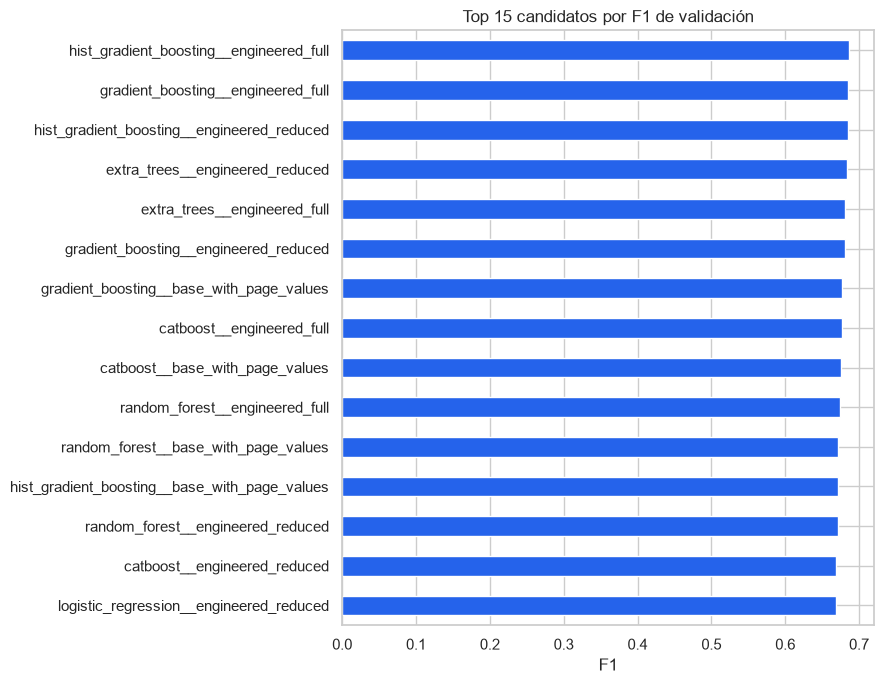

In [6]:
ranked = ranked_results()
fig, ax = plt.subplots(figsize=(9, 7))
ranked.head(15).set_index("run_name")["f1"].sort_values().plot.barh(ax=ax, color="#2563eb")
ax.set(title="Top 15 candidatos por F1 de validación", xlabel="F1", ylabel="")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "experiments_top_candidates.png", dpi=150)
plt.show()


## Experimento 3 — ensambles de árboles

Dos técnicas de ensamble sobre los mejores candidatos:

1. **Stacking** de Random Forest + Extra Trees + HistGradientBoosting (todos
   scikit-learn, mismo preprocesamiento) con un meta-modelo de regresión
   logística, sobre el conjunto de variables que mejor resultó hasta ahora.
2. **Blend** manual (promedio de probabilidades) entre el mejor árbol
   scikit-learn y el mejor CatBoost, que no comparten preprocesamiento.


In [7]:
best_feature_set = ranked.iloc[0]["feature_set"]

stacking_estimator = StackingClassifier(
    estimators=[
        (
            "random_forest",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_SEED,
            ),
        ),
        (
            "extra_trees",
            ExtraTreesClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_SEED,
            ),
        ),
        (
            "hist_gradient_boosting",
            HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_SEED),
        ),
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    stack_method="predict_proba",
    n_jobs=-1,
)
stacking_run_name = f"stacking_trees__{best_feature_set}"
fit_sklearn_candidate(stacking_run_name, stacking_estimator, best_feature_set, log_artifact=True)

ranked = ranked_results()
best_tree_row = ranked[(ranked["family"] == "sklearn") & (ranked["model"] != "LogisticRegression")].iloc[0]
best_catboost_row = ranked[ranked["family"] == "catboost"].iloc[0]

blend_run_name = f"blend__{best_tree_row['run_name']}__{best_catboost_row['run_name']}"
MODEL_REGISTRY[blend_run_name] = {
    "kind": "blend",
    "member_a": best_tree_row["run_name"],
    "member_b": best_catboost_row["run_name"],
    "weight_a": 0.5,
    "weight_b": 0.5,
}
blend_probabilities = predict_proba_for_run(blend_run_name, validation_fe)
blend_threshold = select_f1_threshold(y_validation.to_numpy(), blend_probabilities)
blend_metrics = evaluate_probabilities(y_validation, blend_probabilities, blend_threshold)
blend_params = {
    "family": "blend",
    "model": f"{best_tree_row['model']}+CatBoost",
    "feature_set": f"{best_tree_row['feature_set']}+{best_catboost_row['feature_set']}",
    "member_a": best_tree_row["run_name"],
    "member_b": best_catboost_row["run_name"],
    "weight_a": 0.5,
    "weight_b": 0.5,
}
_log_candidate(blend_run_name, blend_params, blend_metrics, blend_threshold)

ranked_results().head(10)


2026/08/17 18:54:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/17 18:54:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/17 18:54:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


,run_name,family,model,feature_set,f1,pr_auc,roc_auc,precision,recall,threshold
0,stacking_trees__engineered_full,sklearn,StackingClassifier,engineered_full,0.686327,0.736926,0.929739,0.701370,0.671916,0.471552
1,hist_gradient_boosting__engineered_full,sklearn,HistGradientBoostingClassifier,engineered_full,0.685930,0.737829,0.927924,0.657831,0.716535,0.627264
2,blend__stacking_trees__engineered_full__catboo...,blend,StackingClassifier+CatBoost,engineered_full+engineered_full,0.684896,0.746856,0.933158,0.679587,0.690289,0.609980
3,gradient_boosting__engineered_full,sklearn,GradientBoostingClassifier,engineered_full,0.684636,0.753709,0.932798,0.703601,0.666667,0.443684
4,hist_gradient_boosting__engineered_reduced,sklearn,HistGradientBoostingClassifier,engineered_reduced,0.684411,0.737866,0.929921,0.661765,0.708661,0.654818
5,extra_trees__engineered_reduced,sklearn,ExtraTreesClassifier,engineered_reduced,0.683673,0.733483,0.927626,0.665012,0.703412,0.564056
6,extra_trees__engineered_full,sklearn,ExtraTreesClassifier,engineered_full,0.680958,0.719069,0.923839,0.655340,0.708661,0.531420
7,gradient_boosting__engineered_reduced,sklearn,GradientBoostingClassifier,engineered_reduced,0.680328,0.751777,0.932474,0.709402,0.653543,0.460263
8,gradient_boosting__base_with_page_values,sklearn,GradientBoostingClassifier,base_with_page_values,0.676806,0.741546,0.930159,0.654412,0.700787,0.381456
9,catboost__engineered_full,catboost,CatBoostClassifier,engineered_full,0.676316,0.747106,0.932589,0.678100,0.674541,0.805363


## Ajuste fino de hiperparámetros para CatBoost

Se explora un barrido pequeño de `depth` y `learning_rate` alrededor del
conjunto de variables donde CatBoost obtuvo el mejor F1, ya que fue el
modelo explícitamente solicitado para explorar en profundidad.


In [8]:
tuning_feature_set = best_catboost_row["feature_set"]
CATBOOST_GRID = [
    {"depth": 4, "learning_rate": 0.1},
    {"depth": 6, "learning_rate": 0.05},
    {"depth": 6, "learning_rate": 0.1},
    {"depth": 8, "learning_rate": 0.03},
    {"depth": 8, "learning_rate": 0.1},
    {"depth": 10, "learning_rate": 0.03},
]
for index, grid_params in enumerate(CATBOOST_GRID):
    fit_catboost_candidate(
        f"catboost_tuning_{index}__{tuning_feature_set}", tuning_feature_set, catboost_params=grid_params
    )

ranked = ranked_results()
ranked.head(10)


,run_name,family,model,feature_set,f1,pr_auc,roc_auc,precision,recall,threshold
0,stacking_trees__engineered_full,sklearn,StackingClassifier,engineered_full,0.686327,0.736926,0.929739,0.701370,0.671916,0.471552
1,hist_gradient_boosting__engineered_full,sklearn,HistGradientBoostingClassifier,engineered_full,0.685930,0.737829,0.927924,0.657831,0.716535,0.627264
2,blend__stacking_trees__engineered_full__catboo...,blend,StackingClassifier+CatBoost,engineered_full+engineered_full,0.684896,0.746856,0.933158,0.679587,0.690289,0.609980
3,gradient_boosting__engineered_full,sklearn,GradientBoostingClassifier,engineered_full,0.684636,0.753709,0.932798,0.703601,0.666667,0.443684
4,hist_gradient_boosting__engineered_reduced,sklearn,HistGradientBoostingClassifier,engineered_reduced,0.684411,0.737866,0.929921,0.661765,0.708661,0.654818
5,extra_trees__engineered_reduced,sklearn,ExtraTreesClassifier,engineered_reduced,0.683673,0.733483,0.927626,0.665012,0.703412,0.564056
6,catboost_tuning_4__engineered_full,catboost,CatBoostClassifier,engineered_full,0.682667,0.746949,0.931556,0.693767,0.671916,0.793764
7,catboost_tuning_2__engineered_full,catboost,CatBoostClassifier,engineered_full,0.681818,0.746991,0.933759,0.656934,0.708661,0.777676
8,catboost_tuning_5__engineered_full,catboost,CatBoostClassifier,engineered_full,0.681761,0.739038,0.931684,0.654589,0.711286,0.726978
9,extra_trees__engineered_full,sklearn,ExtraTreesClassifier,engineered_full,0.680958,0.719069,0.923839,0.655340,0.708661,0.531420


## Selección final y evaluación única en test

Se elige el candidato con mayor F1 de validación entre todo lo entrenado en
este notebook (barrido inicial, CatBoost, ensambles y ajuste fino) y se
evalúa **una sola vez** sobre test, igual que en el notebook de producción.
El resultado se registra como un run adicional (`experiment_champion`) y se
guarda en `reports/experiments/model_metrics_experiments.json`, sin tocar los
artefactos de producción (`models/champion.joblib`,
`reports/model_metrics.json`).


In [9]:
champion_row = ranked.iloc[0]
champion_run_name = champion_row["run_name"]
champion_threshold = float(champion_row["threshold"])
champion_entry = MODEL_REGISTRY[champion_run_name]

test_probabilities = predict_proba_for_run(champion_run_name, test_fe)
test_metrics = evaluate_probabilities(y_test, test_probabilities, champion_threshold)

experiment_summary = {
    "champion_run": champion_run_name,
    "champion_family": champion_row["family"],
    "champion_model": champion_row["model"],
    "champion_feature_set": champion_row["feature_set"],
    "champion_threshold": champion_threshold,
    "validation_metrics": {
        key: float(champion_row[key]) for key in ("f1", "pr_auc", "roc_auc", "precision", "recall")
    },
    "test_metrics": test_metrics,
    "all_candidates": ranked.to_dict(orient="records"),
}
write_json(EXPERIMENTS_DIR / "model_metrics_experiments.json", experiment_summary)

with tracked_run(
    tracking_uri=TRACKING_URI,
    experiment_name=EXPERIMENT_NAME,
    run_name="experiment_champion",
    params={
        "candidate": champion_run_name,
        "family": champion_row["family"],
        "model": champion_row["model"],
        "feature_set": champion_row["feature_set"],
        "selection_metric": "f1",
    },
):
    mlflow.log_metrics(
        {f"validation_{key}": value for key, value in experiment_summary["validation_metrics"].items()}
    )
    mlflow.log_metrics({f"test_{key}": float(value) for key, value in test_metrics.items()})
    mlflow.log_metric("threshold", champion_threshold)
    mlflow.log_artifact(str(EXPERIMENTS_DIR / "model_metrics_experiments.json"))
    mlflow.set_tag(
        "note", "candidato experimental; no reemplaza al champion de produccion sin promocion explicita"
    )
    if champion_entry["kind"] == "catboost":
        mlflow.catboost.log_model(champion_entry["object"], "model")
    elif champion_entry["kind"] == "sklearn":
        mlflow.sklearn.log_model(champion_entry["object"], "model", serialization_format="pickle")
    else:
        mlflow.log_dict(
            {key: value for key, value in champion_entry.items() if key != "kind"},
            "blend_config.json",
        )

test_metrics


2026/08/17 18:54:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/17 18:54:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/17 18:54:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


{'roc_auc': 0.9288345007084645,
 'pr_auc': 0.7259338637734589,
 'precision': 0.6885245901639344,
 'recall': 0.6596858638743456,
 'f1': 0.6737967914438503,
 'brier_score': 0.07131778944862162,
 'true_negative': 1970,
 'false_positive': 114,
 'false_negative': 130,
 'true_positive': 252}

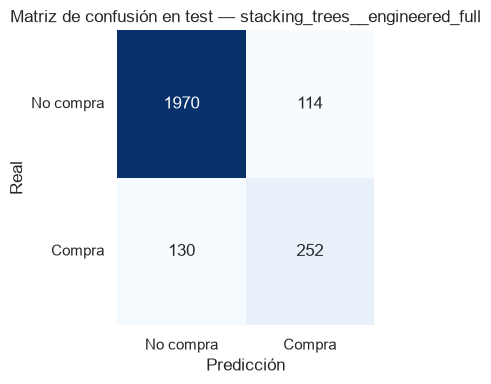

In [10]:
fig, ax = plt.subplots(figsize=(4, 4))
confusion = [
    [test_metrics["true_negative"], test_metrics["false_positive"]],
    [test_metrics["false_negative"], test_metrics["true_positive"]],
]
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set(title=f"Matriz de confusión en test — {champion_run_name}", xlabel="Predicción", ylabel="Real")
ax.set_xticklabels(["No compra", "Compra"])
ax.set_yticklabels(["No compra", "Compra"], rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "experiment_champion_confusion_matrix.png", dpi=150)
plt.show()


In [11]:
if champion_entry["kind"] == "catboost":
    feature_columns = _feature_columns(champion_entry["feature_set"])
    importances = pd.Series(
        champion_entry["object"].get_feature_importance(), index=feature_columns
    ).sort_values()
    fig, ax = plt.subplots(figsize=(7, 8))
    importances.tail(20).plot.barh(ax=ax, color="#2563eb")
    ax.set(title="Importancia de variables — CatBoost", xlabel="Importancia")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "experiment_champion_feature_importance.png", dpi=150)
    plt.show()
elif champion_entry["kind"] == "sklearn" and hasattr(
    champion_entry["object"].named_steps["classifier"], "feature_importances_"
):
    classifier = champion_entry["object"].named_steps["classifier"]
    feature_names = champion_entry["object"].named_steps["preprocess"].get_feature_names_out()
    importances = pd.Series(classifier.feature_importances_, index=feature_names).sort_values()
    fig, ax = plt.subplots(figsize=(7, 8))
    importances.tail(20).plot.barh(ax=ax, color="#2563eb")
    ax.set(title="Importancia de variables", xlabel="Importancia")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "experiment_champion_feature_importance.png", dpi=150)
    plt.show()
else:
    print("El candidato ganador no expone importancias de variable individuales (ensamble heterogéneo).")


El candidato ganador no expone importancias de variable individuales (ensamble heterogéneo).


## Comparación contra el champion de producción


In [12]:
production_metrics = json.loads(PRODUCTION_METRICS_PATH.read_text())
comparison = pd.DataFrame(
    {
        "producción (champion actual)": {
            "modelo": production_metrics["champion"],
            "f1_validation": production_metrics["validation"]["f1"],
            "f1_test": production_metrics["test"]["f1"],
            "pr_auc_test": production_metrics["test"]["pr_auc"],
            "roc_auc_test": production_metrics["test"]["roc_auc"],
        },
        "experimental (este notebook)": {
            "modelo": champion_run_name,
            "f1_validation": experiment_summary["validation_metrics"]["f1"],
            "f1_test": test_metrics["f1"],
            "pr_auc_test": test_metrics["pr_auc"],
            "roc_auc_test": test_metrics["roc_auc"],
        },
    }
).T
comparison


,modelo,f1_validation,f1_test,pr_auc_test,roc_auc_test
producción (champion actual),random_forest__with_page_values,0.671815,0.673469,0.719664,0.927523
experimental (este notebook),stacking_trees__engineered_full,0.686327,0.673797,0.725934,0.928835


## Conclusiones

- Se compararon 5 conjuntos de variables (línea base con/sin `PageValues`,
  variante enriquecida, variante reducida y variante enriquecida sin
  `PageValues`) sobre 5 modelos de scikit-learn, más CatBoost, más dos
  técnicas de ensamble (stacking y blend heterogéneo) y un ajuste fino de
  hiperparámetros de CatBoost: en total, todos los runs quedan en el
  experimento `online-shoppers-purchase-intention-experiments` de MLflow.
- Deliberadamente no se probaron arquitecturas más complejas (redes
  neuronales u otros enfoques de deep learning): el alcance de este
  notebook es explorar árboles ensamblados y CatBoost primero.
- El resultado en `comparison` indica si algún candidato experimental supera
  al champion de producción en F1 de test. Si lo hace de forma consistente
  (y no solo por varianza de una corrida), el siguiente paso natural es
  promoverlo: incorporar la variante ganadora (modelo + conjunto de
  variables) a `online_shoppers.modeling.build_candidate_pipelines` y
  volver a ejecutar el pipeline controlado de `02_model_training.ipynb`,
  que es el único que escribe `models/champion.joblib`.
- Abra `uv run mlflow ui --backend-store-uri sqlite:///mlflow.db` y compare
  ambos experimentos (`online-shoppers-purchase-intention` vs.
  `online-shoppers-purchase-intention-experiments`) para inspeccionar cada
  run, sus parámetros, métricas y artefactos.
